In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt
# tmux attach -t download_torch

from IPython.display import clear_output
from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set_theme(palette='summer')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


'cuda'

## загрузка и осмотр датасета

In [2]:
dataset = datasets.load_dataset('ag_news')
for i in range(5):
    print(f"{dataset['train'][i]['text']} | {dataset['train'][i]['label']}")
    print("-" * 30)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again. | 2
------------------------------
Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market. | 2
------------------------------
Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums. | 2
------------------------------
Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Sat

## подготовка датасета
* cоставим словарь;
* cоздадим класс WordDataset;
* выделим обучающую и тестовую часть, создадим DataLoader-ы.words = Counter()

for example in tqdm(dataset['train']['text']):
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [3]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 11842


In [4]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ]
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])

    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [5]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## функция оценки работы модели

In [6]:
def evaluate(model, eval_dataloader, criterion) -> tuple[float, float]:
    """
    Calculate accuracy on validation dataloader.
    """

    all_logits = []
    all_targets = []
    total_loss = 0

    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'].to(device))
            loss = criterion(logits, batch['label'].to(device))
            total_loss += loss.item()

            all_logits.append(logits.cpu())
            all_targets.append(batch['label'].cpu())

    acc = (torch.cat(all_logits).argmax(dim=1) == torch.cat(all_targets)).float().mean().item()
    avg_loss = total_loss / len(eval_dataloader)
    return avg_loss, acc * 100

In [7]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Valid Loss', linewidth=2)
    ax1.set_title('Training and Valid Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

## baseline

### архитектура модели
- тип слоя: `Vanilla RNN`.

In [8]:
class Baseline(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)

        self.aggregation_type = aggregation_type
        self.agg_factor = 2 if aggregation_type == 'combined' else 1

        self.linear = nn.Linear(hidden_dim * self.agg_factor, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        elif self.aggregation_type == 'combined':
            avg_pool = output.mean(dim=1)
            max_pool = output.max(dim=1)[0]
            output = torch.cat([avg_pool, max_pool], dim=1)
        elif self.aggregation_type == 'last':
            output = output[:, -1, :]
        else:
            raise ValueError("Use 'max', 'mean', 'last' or 'combined'")

        output = self.linear(output)
        output = self.non_lin(output)
        output = self.dropout(output)
        prediction = self.projection(output)
        # output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        # prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

### train loop

In [9]:
agg_types = ['max', 'mean', 'last', 'combined']
colors = ['red', 'blue', 'green', 'orange']

Aggregation: combined | Epoch: 9


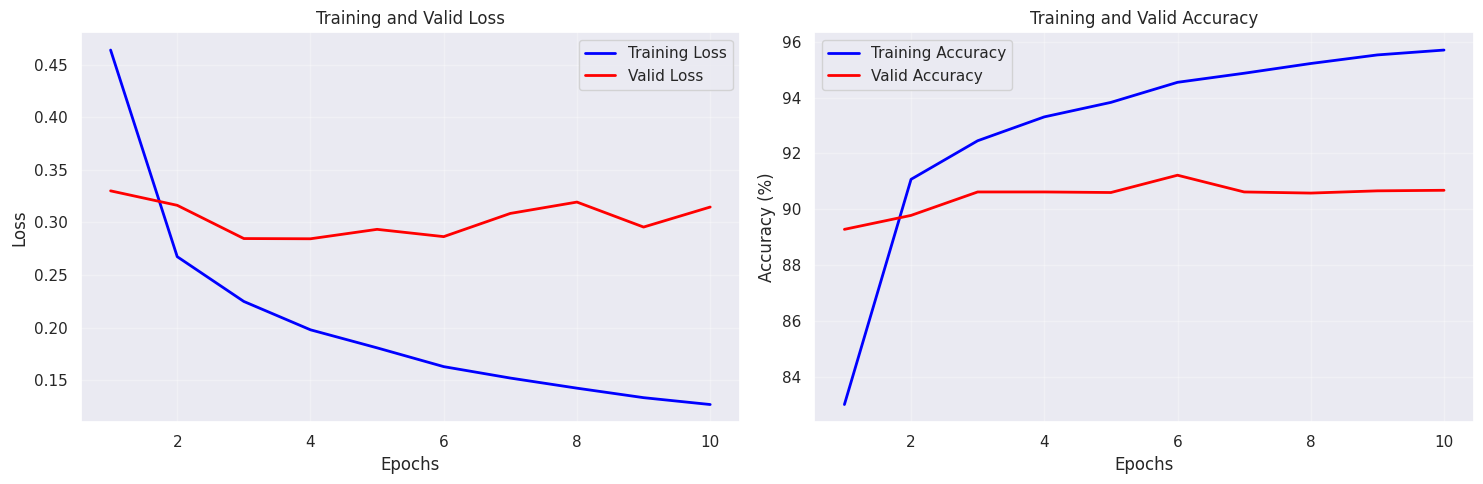

In [10]:
agg_results = {}

num_epoch = 10
for agg_type in agg_types:
    print(f"Starting training for: {agg_type}")

    model = Baseline(hidden_dim=256, vocab_size=len(vocab), aggregation_type=agg_type).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind.get('<pad>', 0))
    optimizer = torch.optim.Adam(model.parameters())

    train_losses, train_accs = [], []
    valid_losses, valid_accs = [], []

    for epoch in range(num_epoch):
        model.train()
        batch_losses = []
        correct_train = 0
        total_train = 0

        for i, batch in enumerate(tqdm(train_dataloader, desc=f'Epoch {epoch}')):
            optimizer.zero_grad()
            ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)

            logits = model(batch['input_ids'].to(device))
            loss = criterion(logits, batch['label'].to(device))
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
            preds = logits.argmax(dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        v_loss, v_acc = evaluate(model, eval_dataloader, criterion)

        train_losses.append(np.mean(batch_losses))
        train_accs.append((correct_train / total_train) * 100)
        valid_losses.append(v_loss)
        valid_accs.append(v_acc)

        clear_output(wait=True)
        print(f"Aggregation: {agg_type} | Epoch: {epoch}")
        plot_metrics(train_losses, train_accs, valid_losses, valid_accs)

    agg_results[f"{agg_type}"] = valid_accs

### агрегация результатов

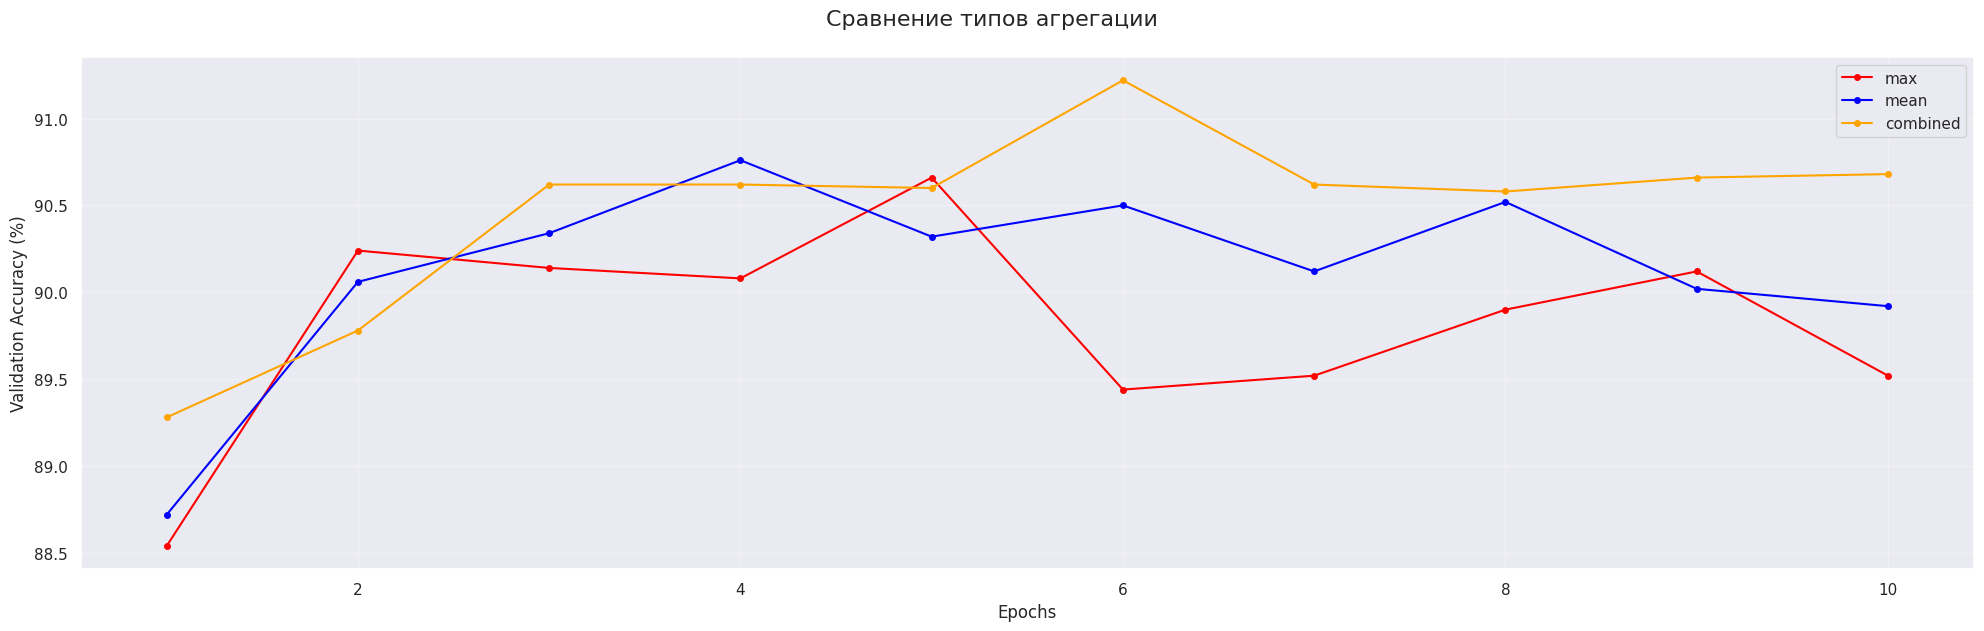

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(20, 6), sharey=True)


for agg_t, color in zip(agg_types, colors):
    key = f"{agg_t}"
    if key == 'last':
      continue
    if key in agg_results:
        ax.plot(range(1, num_epoch + 1), agg_results[key],
                label=agg_t, color=color, marker='o', markersize=4)

ax.set_xlabel("Epochs")
ax.set_ylabel("Validation Accuracy (%)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Сравнение типов агрегации', fontsize=16, y=1.05)
plt.show()

## эксперименты

### архитектура модели
- однослойная сеть;
- тип слоя: `Vanilla RNN`, `LSTM`, `GRU`;
- тип агрегации выходов: `max`, `mean`, `combined`, `last`.

In [12]:
class WordClassifier(nn.Module):
    def __init__(
        self, vocab_size: int, hidden_dim: int, num_classes: int = 4,
        rnn_type: str = 'lstm', num_layers: int = 1,
        bidirectional: bool = False, aggregation_type: str = 'max'
    ):
        super().__init__()
        self.aggregation_type = aggregation_type
        self.agg_factor = 2 if aggregation_type == 'combined' else 1

        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=word2ind['<pad>'])

        rnn_class = getattr(nn, rnn_type.upper())
        self.rnn = rnn_class(
            hidden_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.2 if num_layers > 1 else 0
        )

        rnn_out_dim = hidden_dim * (2 if bidirectional else 1)
        agg_multiplier = 2 if aggregation_type == 'combined' else 1

        self.classifier = nn.Sequential(
            nn.Linear(rnn_out_dim * agg_multiplier, hidden_dim),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, input_ids) -> torch.Tensor:
        # [batch_size, seq_len] -> [batch_size, seq_len, hidden_dim]
        x = self.embedding(input_ids)

        # [batch_size, seq_len, rnn_out_dim]
        output, _ = self.rnn(x)

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1)
        elif self.aggregation_type == 'combined':
            output = torch.cat([output.mean(dim=1), output.max(dim=1)[0]], dim=1)
        elif self.aggregation_type == 'last':
            output = output[:, -1, :]
        else:
            raise ValueError("Invalid aggregation_type")

        return self.classifier(output)

### train loop

In [4]:
rnn_types = ['lstm', 'gru']
agg_types = ['max', 'combined']
layers_configs = [1, 2, 3]
hidden_dims = [128, 256, 512]
colors = ['red', 'blue', 'green', 'orange']

Current: gru_L3_H512_combined | Ep: 2 | Best Acc: 90.88%


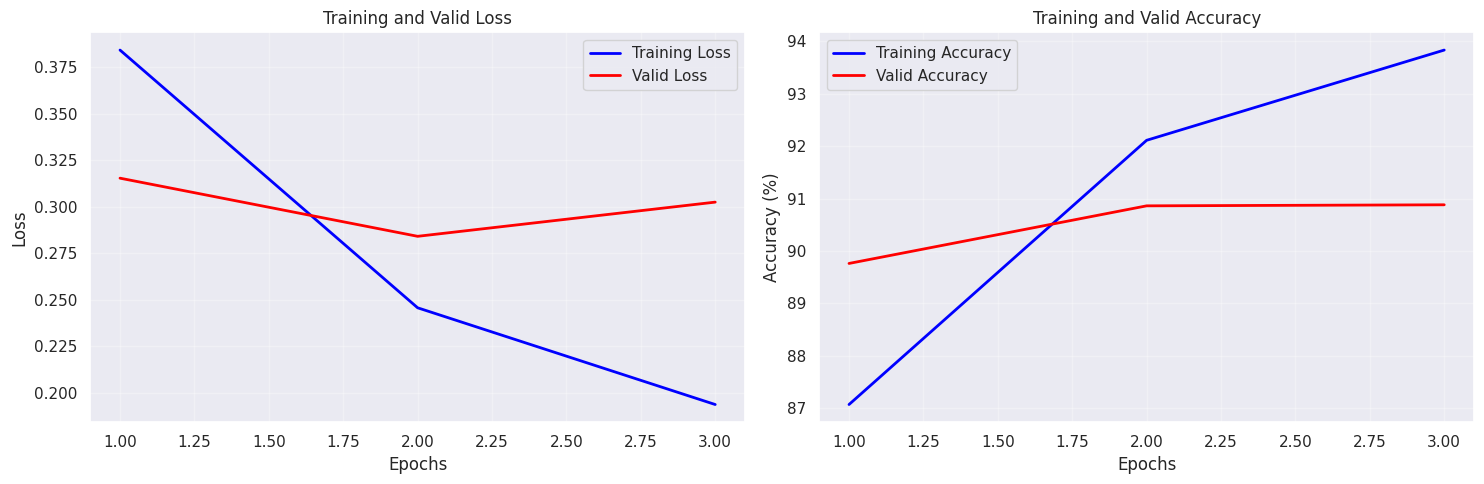

Stopped at epoch 2


In [14]:
agg_results = {}
threshold = 0.1
num_epoch = 10

for r_type in rnn_types:
    for a_type in agg_types:
        for n_layer in layers_configs:
            for h_dim in hidden_dims:
                exp_name = f"{r_type}_L{n_layer}_H{h_dim}_{a_type}"
                print(f"Model: {exp_name}")

                model = WordClassifier(
                    vocab_size=len(vocab),
                    hidden_dim=h_dim,
                    num_classes=4,
                    rnn_type=r_type,
                    num_layers=n_layer,
                    aggregation_type=a_type,
                    bidirectional=True
                ).to(device)

                optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
                criterion = nn.CrossEntropyLoss(ignore_index=word2ind.get('<pad>', 0))

                train_losses, train_accs = [], []
                valid_losses, valid_accs = [], []

                for epoch in range(num_epoch):
                    model.train()
                    batch_losses, correct_train, total_train = [], 0, 0

                    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch}", leave=False):
                        optimizer.zero_grad()
                        ids, labels = batch['input_ids'].to(device), batch['label'].to(device)

                        logits = model(ids)
                        loss = criterion(logits, labels)
                        loss.backward()
                        optimizer.step()

                        batch_losses.append(loss.item())
                        correct_train += (logits.argmax(dim=1) == labels).sum().item()
                        total_train += labels.size(0)

                    # Оценка
                    v_loss, v_acc = evaluate(model, eval_dataloader, criterion)

                    train_losses.append(np.mean(batch_losses))
                    train_accs.append((correct_train / total_train) * 100)
                    valid_losses.append(v_loss)
                    valid_accs.append(v_acc)

                    clear_output(wait=True)
                    print(f"Current: {exp_name} | Ep: {epoch} | Best Acc: {max(valid_accs):.2f}%")
                    plot_metrics(train_losses, train_accs, valid_losses, valid_accs)

                    # ранняя остановка
                    if len(valid_accs) > 1:
                        if (valid_accs[-1] - valid_accs[-2]) < threshold:
                            print(f"Stopped at epoch {epoch}")
                            break

                agg_results[exp_name] = valid_accs

### агрегация результатов

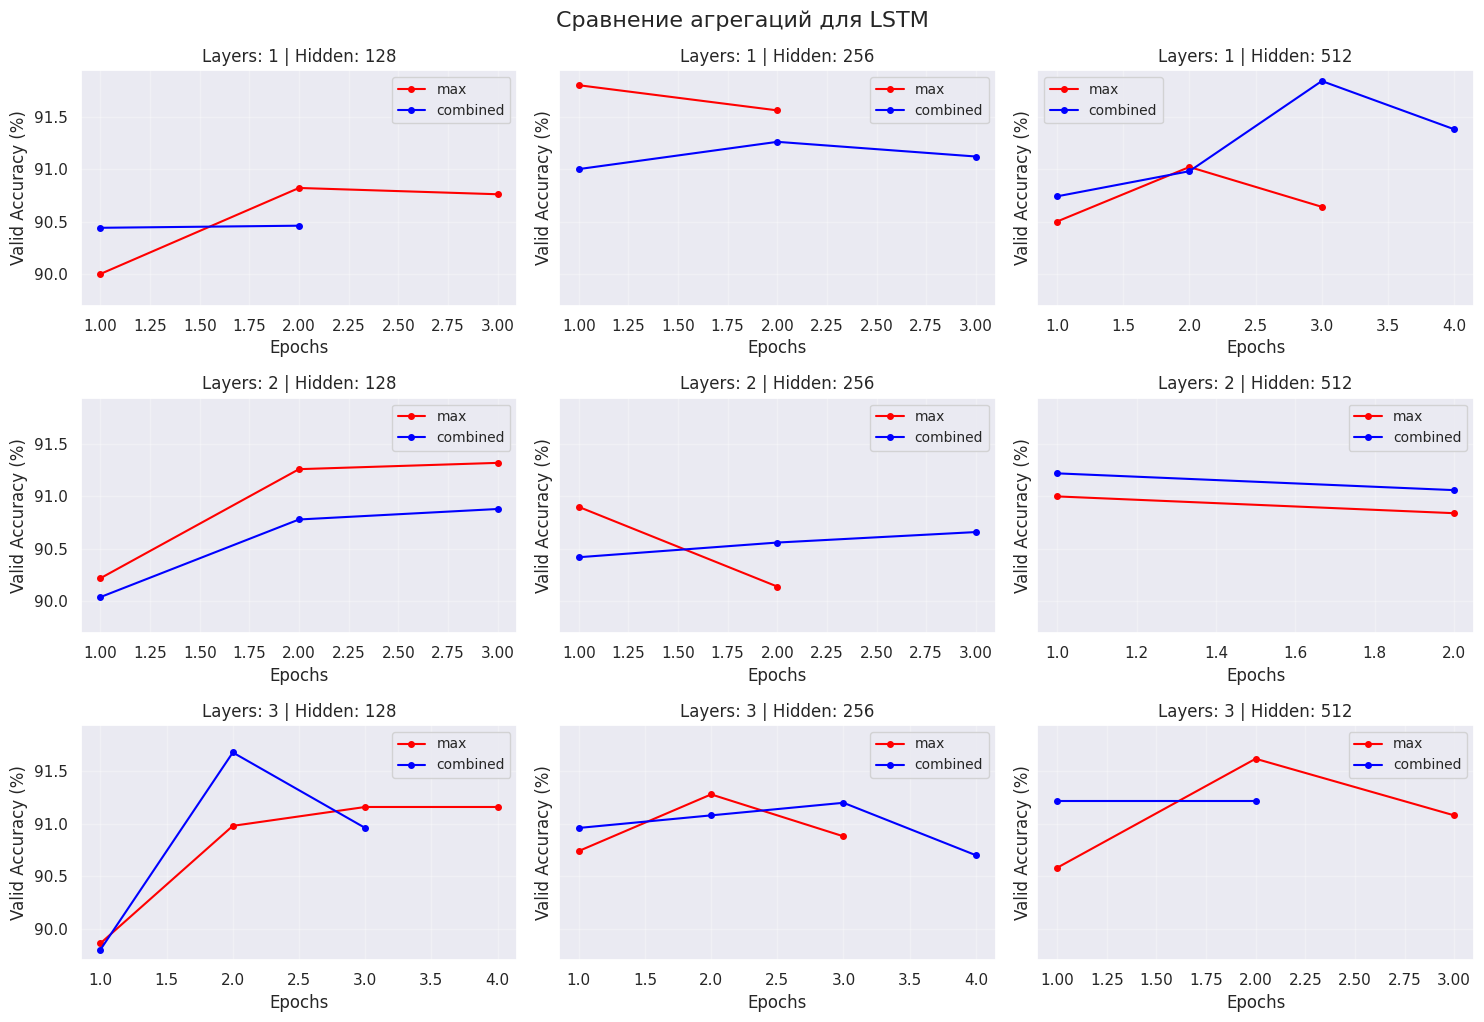

In [ ]:
fig, axes = plt.subplots(len(layers_configs), len(hidden_dims),
                         figsize=(15, 10), sharey=True)

for i, n_layer in enumerate(layers_configs):
    for j, h_dim in enumerate(hidden_dims):
        ax = axes[i, j]

        curr_rnn = 'lstm'
        for agg_t, color in zip(agg_types, colors):
            key = f"{curr_rnn}_L{n_layer}_H{h_dim}_{agg_t}"

            if key in agg_results:
                data = agg_results[key]
                ax.plot(range(1, len(data) + 1), data,
                        label=agg_t, color=color, marker='o', markersize=4)

        ax.set_title(f"Layers: {n_layer} | Hidden: {h_dim}")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Valid Accuracy (%)")
        ax.legend(fontsize='small')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f'Сравнение агрегаций для {curr_rnn.upper()}', fontsize=16, y=1.02)
plt.show()

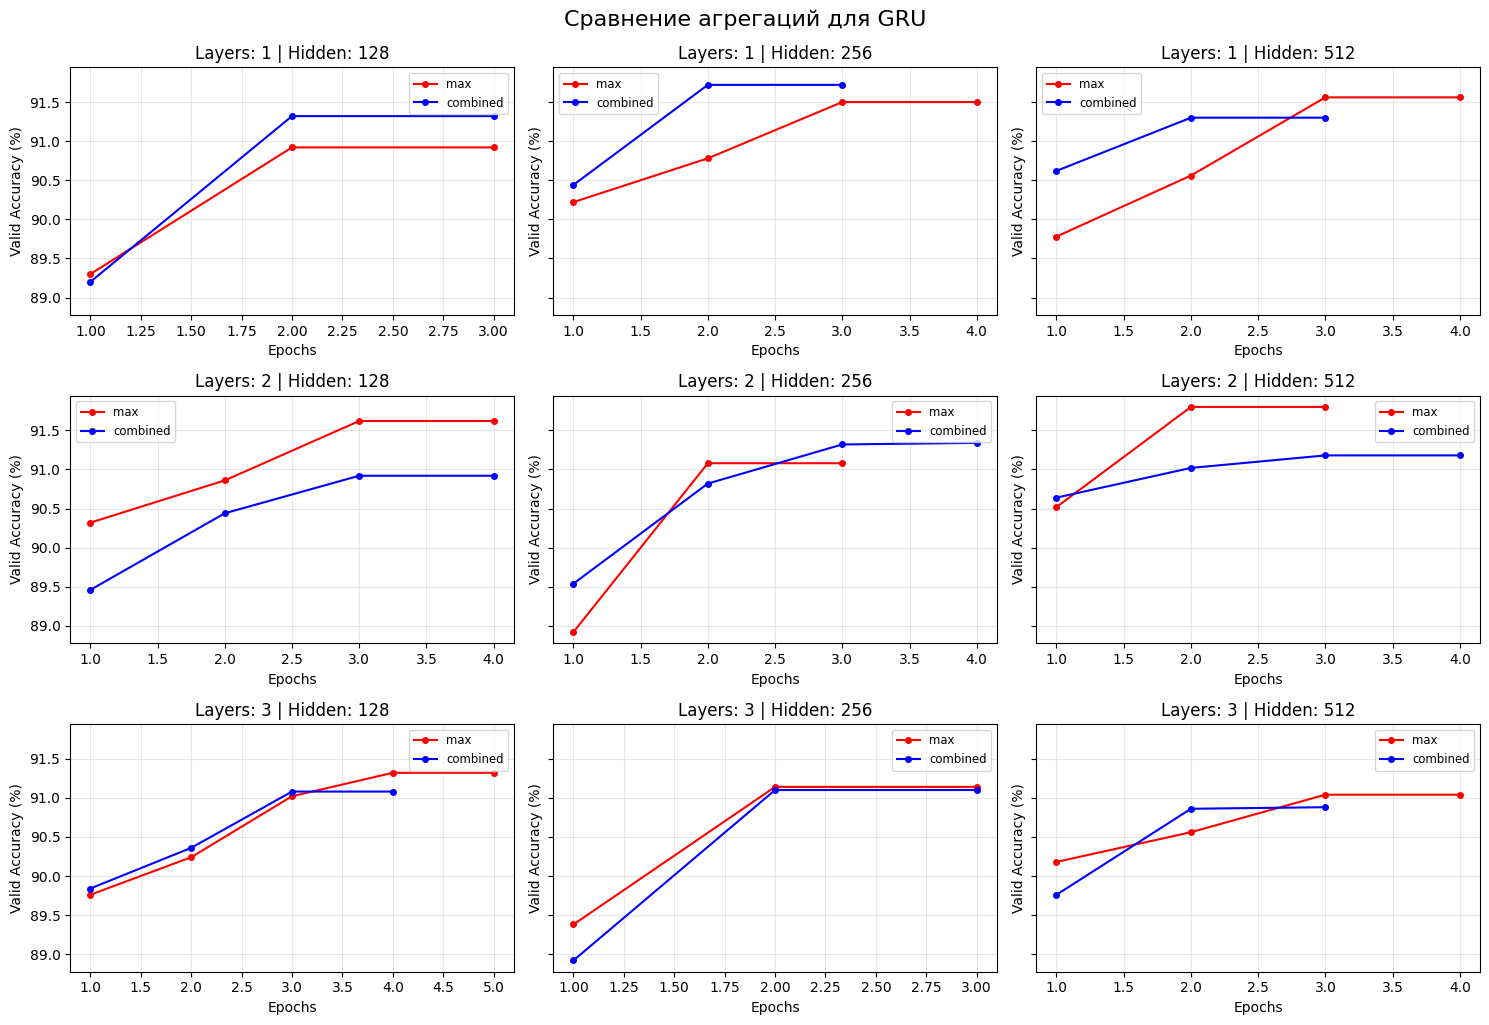

In [ ]:
fig, axes = plt.subplots(len(layers_configs), len(hidden_dims),
                         figsize=(15, 10), sharey=True)

for i, n_layer in enumerate(layers_configs):
    for j, h_dim in enumerate(hidden_dims):
        ax = axes[i, j]

        curr_rnn = 'gru'
        for agg_t, color in zip(agg_types, colors):
            key = f"{curr_rnn}_L{n_layer}_H{h_dim}_{agg_t}"

            if key in agg_results:
                data = agg_results[key]
                ax.plot(range(1, len(data) + 1), data,
                        label=agg_t, color=color, marker='o', markersize=4)

        ax.set_title(f"Layers: {n_layer} | Hidden: {h_dim}")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Valid Accuracy (%)")
        ax.legend(fontsize='small')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f'Сравнение агрегаций для {curr_rnn.upper()}', fontsize=16, y=1.02)
plt.show()

## выводы

### `общие`

* процесс обучения всех моделей характеризуется как нестабильный с существенными осцилляциями качества (например, резкое падение max на графике rnn после 5 эпохи с 90.7% до 89.4%), что показывает высокую чувствительность весов к шумам в данных.

* метод агрегации `last` оказался полностью непригодным для решения задачи и был исключен из визуализации rnn, так как из-за проблемы затухающих градиентов последнее скрытое состояние теряет связь с началом последовательности, что приводит к потере точности.

---

### `тип агрегации признаков`

* агрегация типа `combined` показала лучшие результаты как для lstm (до 92%), так и для gru (пик 91.2% на 6 эпохе). вероятно, потому что объединение max-pooling и mean-pooling позволяет одновременно извлекать наиболее яркие признаки и сохранять общий контекст последовательности, что дает более информативное представление данных по сравнению с использованием этих методов по отдельности.

* метод `mean` показал себя более надежным, чем `max`, в экспериментах с rnn (синяя линия на графике более стабильна к 10 эпохе). так как усреднение сглаживает влияние аномальных признаков в последовательности, а max слишком чувствителен к отдельным выбросам, которые могут не определять общий смысл.

---

### `LSTM`

* увеличение размера скрытого состояния `hidden до 512` в экспериментах с lstm принесло ощутимое улучшение качества, так как большая размерность вектора позволяет модели кодировать более сложные иерархические зависимости в данных, что подтверждается превосходством графиков с hidden: 512 над версиями с 128 и 256 нейронами.

* многослойность `layers = 3` в lstm при малом размере скрытого состояния ускорила первоначальную сходимость, но не дала итогового преимущества перед однослойной широкой моделью. вероятно, потому что избыточная глубина при недостаточной ширине может затруднять прохождение градиента и приводить к более быстрому переобучению.

* оптимальной моделью по совокупности метрик и динамике обучения признана `lstm с параметрами layers: 1, hidden: 512 и типом агрегации combined`, так как у неё самая высокая точность на валидационной выборке (91.8%).

---

### `GRU`

* архитектура показала высокую эффективность при средних размерах скрытого состояния (hidden: 256), максимальная точность почти 91.7% (layers: 1, combined), которая быстрее находит оптимальные веса на малом количестве эпох.

* при увеличении количества слоев до 2-3 наблюдается пересечение эффективности методов агрегации: если на 1 слое лидирует combined (синяя линия), то с ростом глубины метод max (красная линия) часто выходит вперед (например, при layers: 2, hidden: 512 достигает ~91.8%), что может указывать на то, что глубокие gru лучше выделяют ключевые локальные признаки через max-pooling.

* сходимость в целом выглядит более плавной, чем у стандартных rnn, но менее стабильной на финальных стадиях по сравнению с lstm; на многих графиках (например, layers: 1, hidden: 512) видно, что после достижения пика на 3 эпохе качество начинает снижаться или выходить на плато, что требует ранней остановки (early stopping) для предотвращения переобучения.

* подтвердился тезис о неэффективности малых скрытых состояний: для всех конфигураций gru при hidden: 128 точность редко преодолевает порог в 91.3%, в то время как расширение до 256 и 512 позволяет стабильно держаться в диапазоне 91.5–91.8%.

### лучшая модель

`lstm_L1_H512_combined (91.84%)`

### сводная таблица результатов

| архитектура | layers | hidden | агрегация | max valid accuracy (%) | стабильность сходимости |
|-------------|--------|--------|-----------|------------------------|------------------------|
| **lstm** | 1 | 128 | max | 90.82 | высокая (остановка на 2 эпохе, быстрый выход на плато) |
| **lstm** | 1 | 256 | max | 91.80 | высокая (остановка на 1 эпохе, сразу достигнут максимум) |
| **lstm** | 1 | 512 | max | 91.02 | средняя (2 эпохи, плато после 1-й эпохи) |
| **lstm** | 2 | 128 | max | 91.32 | высокая (2 эпохи, стабильный рост) |
| **lstm** | 2 | 256 | max | 90.90 | высокая (остановка на 1 эпохе) |
| **lstm** | 2 | 512 | max | 91.00 | высокая (остановка на 1 эпохе) |
| **lstm** | 3 | 128 | max | 91.16 | средняя (3 эпохи, плавный рост) |
| **lstm** | 3 | 256 | max | 91.28 | средняя (2 эпохи) |
| **lstm** | 3 | 512 | max | 91.62 | средняя (2 эпохи) |
| **lstm** | 1 | 128 | combined | 90.46 | низкая (остановка на 1 эпохе, нет прироста) |
| **lstm** | 1 | 256 | combined | 91.26 | средняя (2 эпохи) |
| **lstm** | 1 | 512 | combined | 91.84 | высокая (3 эпохи, устойчивый рост) |
| **lstm** | 2 | 128 | combined | 90.88 | средняя (2 эпохи) |
| **lstm** | 2 | 256 | combined | 90.66 | низкая (2 эпохи, слабый прирост) |
| **lstm** | 2 | 512 | combined | 91.22 | высокая (остановка на 1 эпохе) |
| **lstm** | 3 | 128 | combined | 91.68 | высокая (2 эпохи, резкий рост) |
| **lstm** | 3 | 256 | combined | 91.20 | средняя (3 эпохи) |
| **lstm** | 3 | 512 | combined | 91.22 | высокая (остановка на 1 эпохе) |
| **gru** | 1 | 128 | max | 90.92 | высокая (2 эпохи) |
| **gru** | 1 | 256 | max | 91.50 | средняя (3 эпохи, плато после 2-й) |
| **gru** | 1 | 512 | max | 91.56 | средняя (3 эпохи, плато после 2-й) |
| **gru** | 2 | 128 | max | 91.62 | высокая (3 эпохи, стабильный рост) |
| **gru** | 2 | 256 | max | 91.08 | средняя (2 эпохи, пик на 1-й) |
| **gru** | 2 | 512 | max | 91.80 | высокая (2 эпохи) |
| **gru** | 3 | 128 | max | 91.32 | средняя (4 эпохи, плато после 3-й) |
| **gru** | 3 | 256 | max | 91.14 | средняя (2 эпохи) |
| **gru** | 3 | 512 | max | 91.04 | низкая (3 эпохи, слабый прирост) |
| **gru** | 1 | 128 | combined | 91.32 | высокая (2 эпохи) |
| **gru** | 1 | 256 | combined | 91.72 | высокая (2 эпохи) |
| **gru** | 1 | 512 | combined | 91.30 | высокая (2 эпохи) |
| **gru** | 2 | 128 | combined | 90.92 | низкая (3 эпохи, медленный рост) |
| **gru** | 2 | 256 | combined | 91.34 | средняя (3 эпохи) |
| **gru** | 2 | 512 | combined | 91.18 | средняя (3 эпохи) |
| **gru** | 3 | 128 | combined | 91.08 | средняя (3 эпохи) |
| **gru** | 3 | 256 | combined | 91.10 | высокая (2 эпохи) |
| **gru** | 3 | 512 | combined | 90.88 | низкая (2 эпохи, отсутствие роста) |